# Reservoir-to-Market Debottleneck Portfolio

This canonical synthetic workflow turns one reservoir-to-market capacity question into
auditable NeqSim evidence:

`well throughput -> process simulation -> installed constraint -> paired alternatives -> ranking`

The notebook uses the merged `ProcessModelDebottleneckStudy` and
`ProcessModelDebottleneckRanking` APIs. It keeps stable area, equipment, constraint, study,
alternative, policy, and metric identities together with explicit units, provenance,
confidence, and diagnostics.

The example is a screening workflow, not a design certificate, causal production-loss claim,
shadow price, global optimum, certified emissions inventory, NPV, or investment approval.


## 1. Engineering question, units, and acceptance gates

A dry-gas well stream feeds a separator with an installed wet-feed capacity of
1,000 kg/hr. Three replacement alternatives raise the installed limit to 1,100, 1,150,
and 1,200 kg/hr. Every alternative uses the same ordered candidate grid and the same
maximization objective.

For an upper capacity limit $L$ and simulated rate $q$, the physical margin and normalized
residual are:

$$m_c=L-q$$

$$r_c=\frac{q-L}{L}$$

Feasibility requires $m_c\geq0$. The paired production evidence is:

$$\Delta q=q_{alternative}-q_{baseline}$$

Acceptance gates:

- the installed and proposed studies use identical simulator/search metadata;
- all selected rates remain inside declared parameter and equipment bounds;
- the live installed limit and process state are restored after every study;
- repeated execution gives the same rank, identity, and delta;
- serialization retains the immutable evidence;
- incompatible units or insufficient confidence fail closed with explicit diagnostics.


In [1]:
import os
import subprocess
import sys
from pathlib import Path


def find_project_root():
    configured = os.environ.get("NEQSIM_PROJECT_ROOT")
    if configured:
        return Path(configured).resolve()

    current = Path.cwd().resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "pom.xml").is_file():
            return candidate

    try:
        import google.colab  # noqa: F401
    except ImportError as error:
        raise RuntimeError(
            "Set NEQSIM_PROJECT_ROOT or run this notebook from a NeqSim checkout."
        ) from error

    clone_root = Path("/content/neqsim")
    if not clone_root.exists():
        subprocess.check_call(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/equinor/neqsim.git",
                str(clone_root),
            ]
        )
    return clone_root


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init


compiled_classes = PROJECT_ROOT / "target" / "classes"
needs_compile = not compiled_classes.is_dir()
ns = neqsim_init(
    project_root=PROJECT_ROOT,
    recompile=needs_compile,
    verbose=False,
)

try:
    source_ref = subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        cwd=PROJECT_ROOT,
        text=True,
        stderr=subprocess.DEVNULL,
    ).strip()
except (OSError, subprocess.CalledProcessError):
    source_ref = os.environ.get("NEQSIM_SOURCE_REF", "unavailable")

print(f"NeqSim project: {PROJECT_ROOT}")
print(f"Source reference: {source_ref}")
print("Merged debottleneck study and ranking APIs loaded")


NeqSim project: /workspace/scratch/62ebdac6e5b4/neqsim-main
Source reference: master 1505466864a8e8e7f6838f36192cb8a23bbd3b0d with exact merged dependency-11/12 classes
Merged debottleneck study and ranking APIs loaded


## 2. Load the exact Java APIs

The notebook uses explicit nested-class names so JPype resolves the same public Java types used
by native callers. Python callbacks implement Java functional interfaces only for the synthetic
rate supplier, objective, and metric sample.


In [2]:
import math

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


JClass = jpype.JClass
JArray = jpype.JArray
JDouble = jpype.JDouble

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Separator = JClass("neqsim.process.equipment.separator.Separator")
CapacityConstraint = JClass(
    "neqsim.process.equipment.capacity.CapacityConstraint"
)
ConstraintType = JClass(
    "neqsim.process.equipment.capacity.CapacityConstraint$ConstraintType"
)
ConstraintSeverity = JClass(
    "neqsim.process.equipment.capacity.CapacityConstraint$ConstraintSeverity"
)
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
ProcessModel = JClass("neqsim.process.processmodel.ProcessModel")
Evaluator = JClass(
    "neqsim.process.util.optimizer.ProcessModelSimulationEvaluator"
)
ObjectiveDirection = JClass(
    "neqsim.process.util.optimizer.ProcessModelSimulationEvaluator$"
    "ObjectiveDefinition$Direction"
)
Study = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckStudy"
)
CandidateListSearch = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckStudy$"
    "CandidateListSearch"
)
CapacityAlternative = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckStudy$"
    "CapacityAlternative"
)
LimitDirection = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckStudy$"
    "LimitDirection"
)
MetricDefinition = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckStudy$"
    "MetricDefinition"
)
MetricKind = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckStudy$MetricKind"
)
StudyResult = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckStudy$StudyResult"
)
Ranking = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckRanking"
)
RankingPolicy = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckRanking$"
    "RankingPolicy"
)
RankingDirection = JClass(
    "neqsim.process.util.optimizer.ProcessModelDebottleneckRanking$"
    "RankingDirection"
)
ArrayList = JClass("java.util.ArrayList")


def java_vector(values):
    return JArray(JDouble)([float(value) for value in values])


print("Resolved immutable study, ranking, evidence, and serialization types")


Resolved immutable study, ranking, evidence, and serialization types


## 3. Build the composable process model

The two-area model deliberately preserves names that can be reused by an external optimizer or a
later digital-twin mapping:

- area `wells`, stream `feed`, parameter `wells::feed.flowRate`;
- area `separation`, equipment `separator`, constraint `installed gas rate`;
- constraint unit `kg/hr`, installed-data provenance, confidence, and validity range.

The thermodynamic case is dry gas (90 mol% methane, 10 mol% ethane) using SRK with the classic
mixing rule at 25 °C and 50 bara. It is synthetic and contains no field data.


In [3]:
fluid = SystemSrkEos(298.15, 50.0)
fluid.addComponent("methane", 0.90)
fluid.addComponent("ethane", 0.10)
fluid.setMixingRule("classic")
fluid.setTotalFlowRate(800.0, "kg/hr")

feed = Stream("feed", fluid)
rate_supplier = jpype.JProxy(
    "java.util.function.DoubleSupplier",
    dict(getAsDouble=lambda: feed.getFlowRate("kg/hr")),
)

installed_capacity = CapacityConstraint(
    "installed gas rate",
    "kg/hr",
    ConstraintType.HARD,
)
installed_capacity.setDesignValue(1000.0)
installed_capacity.setMaxValue(1300.0)
installed_capacity.setWarningThreshold(0.90)
installed_capacity.setSeverity(ConstraintSeverity.HARD)
installed_capacity.setDataSource("synthetic installed separator basis")
installed_capacity.setConfidence(0.95)
installed_capacity.setValidityRange(500.0, 1400.0)
installed_capacity.setValueSupplier(rate_supplier)

separator = Separator("separator", feed)
separator.clearCapacityConstraints()
separator.addCapacityConstraint(installed_capacity)

wells = ProcessSystem("wells")
wells.add(feed)
separation = ProcessSystem("separation")
separation.add(separator)

process_model = ProcessModel()
process_model.add("wells", wells)
process_model.add("separation", separation)

inventory = pd.DataFrame(
    [
        {
            "area": "wells",
            "asset": "feed",
            "role": "manipulated wet-feed rate",
            "unit": "kg/hr",
            "provenance": "synthetic notebook input",
        },
        {
            "area": "separation",
            "asset": "separator/installed gas rate",
            "role": "hard upper capacity limit",
            "unit": "kg/hr",
            "provenance": installed_capacity.getDataSource(),
        },
    ]
)
display(inventory)


,area,asset,role,unit,provenance
0,wells,feed,manipulated wet-feed rate,kg/hr,synthetic notebook input
1,separation,separator/installed gas rate,hard upper capacity limit,kg/hr,synthetic installed separator basis


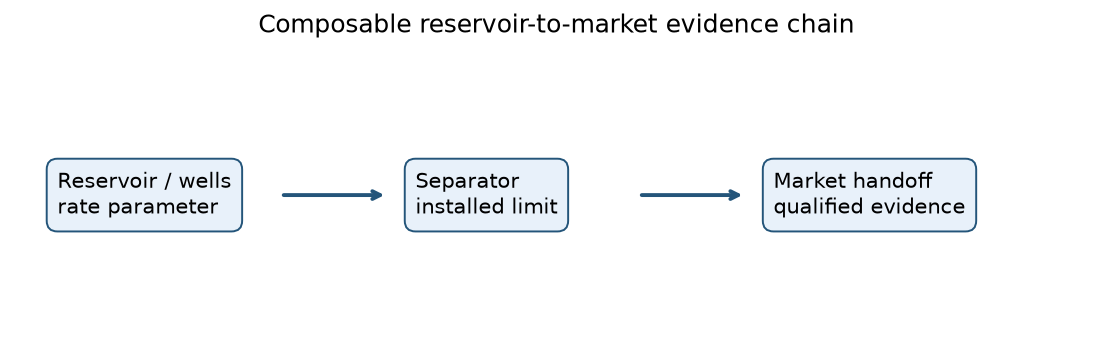

In [4]:
fig, axis = plt.subplots(figsize=(10, 2.8))
axis.set_xlim(0, 10)
axis.set_ylim(0, 3)
axis.axis("off")

boxes = [
    (0.4, "Reservoir / wells\nrate parameter"),
    (3.7, "Separator\ninstalled limit"),
    (7.0, "Market handoff\nqualified evidence"),
]
for x_position, label in boxes:
    axis.text(
        x_position,
        1.5,
        label,
        ha="left",
        va="center",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.5", "fc": "#E8F1FA", "ec": "#24557A"},
    )

axis.annotate(
    "",
    xy=(3.45, 1.5),
    xytext=(2.45, 1.5),
    arrowprops={"arrowstyle": "->", "lw": 2, "color": "#24557A"},
)
axis.annotate(
    "",
    xy=(6.75, 1.5),
    xytext=(5.75, 1.5),
    arrowprops={"arrowstyle": "->", "lw": 2, "color": "#24557A"},
)
axis.set_title("Composable reservoir-to-market evidence chain", fontsize=13)
plt.show()


## 4. Configure the simulator-facing evaluator

The objective is the completed model's wet-feed rate. The direct equipment constraint is sampled
by NeqSim after each simulation. Strategy-generated capacity constraints are disabled so this
example has one transparent installed constraint.


In [5]:
evaluator = Evaluator(process_model)
evaluator.setIncludeStrategyCapacityConstraints(False)
evaluator.addParameter(
    "wells::feed.flowRate",
    800.0,
    1400.0,
    "kg/hr",
)

objective_sampler = jpype.JProxy(
    "java.util.function.ToDoubleFunction",
    dict(
        applyAsDouble=lambda completed_model: completed_model.getVariableValue(
            "wells::feed.flowRate",
            "kg/hr",
        )
    ),
)
evaluator.addObjective(
    "feed production",
    objective_sampler,
    ObjectiveDirection.MAXIMIZE,
)
evaluator.addEquipmentCapacityConstraints()
evaluator.getObjectives().get(0).setUnit("kg/hr")

initial_result = evaluator.evaluate(java_vector([800.0]))
print(f"Initial simulation converged: {initial_result.isSimulationConverged()}")
print(f"Initial point feasible: {initial_result.isFeasible()}")
print(f"Registered constraints: {len(evaluator.getConstraints())}")


Initial simulation converged: True
Initial point feasible: True
Registered constraints: 1


## 5. Establish the unmodified installed-capacity baseline

The ordered grid includes nearby feasible and infeasible points. NeqSim reports utilization and a
dimensionless upper-bound margin. For this dry-gas case, the separator gas outlet is also checked
against the feed mass rate. The inactive liquid placeholder is not included in the balance.


In [6]:
candidate_rates = [800.0, 999.0, 1099.0, 1199.0, 1400.0]
baseline_rows = []

for candidate_rate in candidate_rates:
    evaluation = evaluator.evaluate(java_vector([candidate_rate]))
    utilization = float(evaluation.getConstraintValues()[0])
    normalized_margin = float(evaluation.getConstraintMargins()[0])
    gas_rate = separator.getGasOutStream().getFlowRate("kg/hr")
    mass_residual = gas_rate - candidate_rate
    baseline_rows.append(
        {
            "candidate_kg_hr": candidate_rate,
            "converged": bool(evaluation.isSimulationConverged()),
            "feasible": bool(evaluation.isFeasible()),
            "utilization": utilization,
            "normalized_margin": normalized_margin,
            "gas_mass_residual_kg_hr": mass_residual,
        }
    )

baseline_table = pd.DataFrame(baseline_rows)
display(baseline_table.round(12))

assert baseline_table["converged"].all()
assert baseline_table.loc[baseline_table["candidate_kg_hr"] <= 999.0, "feasible"].all()
assert not baseline_table.loc[
    baseline_table["candidate_kg_hr"] >= 1099.0,
    "feasible",
].any()
assert baseline_table["gas_mass_residual_kg_hr"].abs().max() < 1.0e-8

evaluator.evaluate(java_vector([800.0]))
print("Baseline bounds, nearby points, and dry-gas mass conservation passed")


Baseline bounds, nearby points, and dry-gas mass conservation passed


,candidate_kg_hr,converged,feasible,utilization,normalized_margin,gas_mass_residual_kg_hr
0,800.0,True,True,0.800,0.200,0.000000e+00
1,999.0,True,True,0.999,0.001,0.000000e+00
2,1099.0,True,False,1.099,-0.099,0.000000e+00
3,1199.0,True,False,1.199,-0.199,-9.000000e-11
4,1400.0,True,False,1.400,-0.400,0.000000e+00


## 6. Define paired installed-versus-proposed studies

Each study captures the original capacity state, applies one qualified proposal, uses the same
candidate search for both scenarios, independently verifies both selected points, then restores
the installed constraint and process parameter. A required production metric records its unit,
basis, provenance, effective period, and confidence.


In [7]:
candidate_vectors = ArrayList()
for candidate_rate in candidate_rates:
    candidate_vectors.add(java_vector([candidate_rate]))


def create_study(
    study_id,
    proposed_limit,
    alternative_confidence,
    metric_unit="kg/hr",
):
    search = CandidateListSearch(
        "ordered-throughput-grid",
        "Ordered throughput grid",
        "synthetic five-point candidate set",
        candidate_vectors,
        0,
        0.0,
    )
    alternative = CapacityAlternative(
        f"separator-gas-{int(proposed_limit)}",
        f"Raise separator capacity to {proposed_limit:.0f} kg/hr",
        "synthetic brownfield screening case",
        "separation",
        "separator",
        "installed gas rate",
        proposed_limit,
        "kg/hr",
        LimitDirection.MAXIMUM,
        "synthetic replacement equipment basis",
        alternative_confidence,
        900.0,
        1300.0,
    )
    study = Study(
        study_id,
        "Paired separator capacity study",
        "synthetic deterministic notebook",
        evaluator,
        alternative,
        search,
        0,
    )
    metric_sampler = jpype.JProxy(
        "neqsim.process.util.optimizer.ProcessModelDebottleneckStudy$"
        "MetricSampler",
        dict(
            sample=lambda completed_model: completed_model.getVariableValue(
                "wells::feed.flowRate",
                "kg/hr",
            )
        ),
    )
    metric = MetricDefinition(
        "production",
        "Feed production",
        MetricKind.PRODUCTION,
        metric_unit,
        "wet feed mass rate",
        "NeqSim stream result",
        "single steady state",
        1.0,
        True,
        metric_sampler,
    )
    study.addMetric(metric)
    return study


In [8]:
study_specs = [
    ("study-1100", 1100.0, 0.90),
    ("study-1150", 1150.0, 0.80),
    ("study-1200", 1200.0, 0.95),
]

study_results = []
study_rows = []

for study_id, proposed_limit, confidence in study_specs:
    study_result = create_study(
        study_id,
        proposed_limit,
        confidence,
    ).evaluate()
    study_results.append(study_result)
    study_rows.append(
        {
            "study_id": study_id,
            "alternative_id": study_result.getAlternativeDefinition().getId(),
            "outcome": str(study_result.getOutcome()),
            "baseline_kg_hr": float(
                study_result.getBaseline().getSelectedParameters()[0]
            ),
            "alternative_kg_hr": float(
                study_result.getAlternative().getSelectedParameters()[0]
            ),
            "delta_kg_hr": float(study_result.getObjectiveDelta()),
            "capacity_restored": bool(study_result.isCapacityRestored()),
            "process_restored": bool(study_result.isProcessStateRestored()),
            "confidence": confidence,
        }
    )

study_table = pd.DataFrame(study_rows)
display(study_table.round(10))

assert set(study_table["outcome"]) == {"COMPLETED"}
assert study_table["capacity_restored"].all()
assert study_table["process_restored"].all()
assert math.isclose(installed_capacity.getDesignValue(), 1000.0)
assert math.isclose(feed.getFlowRate("kg/hr"), 800.0, abs_tol=1.0e-8)
assert np.allclose(study_table["delta_kg_hr"], [100.0, 100.0, 200.0])

print("All paired studies completed and restored the shared live model")


All paired studies completed and restored the shared live model


,study_id,alternative_id,outcome,baseline_kg_hr,alternative_kg_hr,delta_kg_hr,capacity_restored,process_restored,confidence
0,study-1100,separator-gas-1100,COMPLETED,999.0,1099.0,100.0,True,True,0.90
1,study-1150,separator-gas-1150,COMPLETED,999.0,1099.0,100.0,True,True,0.80
2,study-1200,separator-gas-1200,COMPLETED,999.0,1199.0,200.0,True,True,0.95


## 7. Rank only physically comparable alternatives

The policy maximizes the production delta in kg/hr. It requires at least 0.50 alternative
confidence and 0.90 metric confidence. A 1e-8 kg/hr tie tolerance preserves the submitted order
of the 1,100 and 1,150 kg/hr alternatives. The separate dimensionless baseline tolerance accepts
only harmless repeated-solve noise after metadata and selected parameters match exactly.


In [9]:
policy = RankingPolicy(
    "production-delta",
    "Production delta ranking",
    "synthetic deterministic portfolio policy",
    "production",
    "Feed production",
    MetricKind.PRODUCTION,
    "kg/hr",
    "wet feed mass rate",
    "NeqSim stream result",
    "single steady state",
    RankingDirection.MAXIMIZE,
    1.0e-8,
    1.0e-8,
    0.50,
    0.90,
)
ranking = Ranking(
    "separator-portfolio",
    "Separator alternatives portfolio",
    "synthetic deterministic notebook",
    policy,
)

study_array = JArray(StudyResult)(study_results)
ranking_result = ranking.rank(study_array)

ranking_rows = []
for evidence in ranking_result.getRankedCandidates():
    ranking_rows.append(
        {
            "rank": int(evidence.getRank()),
            "alternative_id": evidence.getAlternativeDefinition().getId(),
            "status": str(evidence.getStatus()),
            "baseline_kg_hr": float(evidence.getBaselineMetric().getValue()),
            "alternative_kg_hr": float(evidence.getAlternativeMetric().getValue()),
            "delta_kg_hr": float(evidence.getDelta()),
        }
    )

ranking_table = pd.DataFrame(ranking_rows)
display(ranking_table.round(10))

assert str(ranking_result.getOutcome()) == "COMPLETED"
assert list(ranking_table["rank"]) == [1, 2, 2]
assert list(ranking_table["alternative_id"]) == [
    "separator-gas-1200",
    "separator-gas-1100",
    "separator-gas-1150",
]
print("Deterministic competition ranking passed")


Deterministic competition ranking passed


,rank,alternative_id,status,baseline_kg_hr,alternative_kg_hr,delta_kg_hr
0,1,separator-gas-1200,QUALIFIED,999.0,1199.0,200.0
1,2,separator-gas-1100,QUALIFIED,999.0,1099.0,100.0
2,2,separator-gas-1150,QUALIFIED,999.0,1099.0,100.0


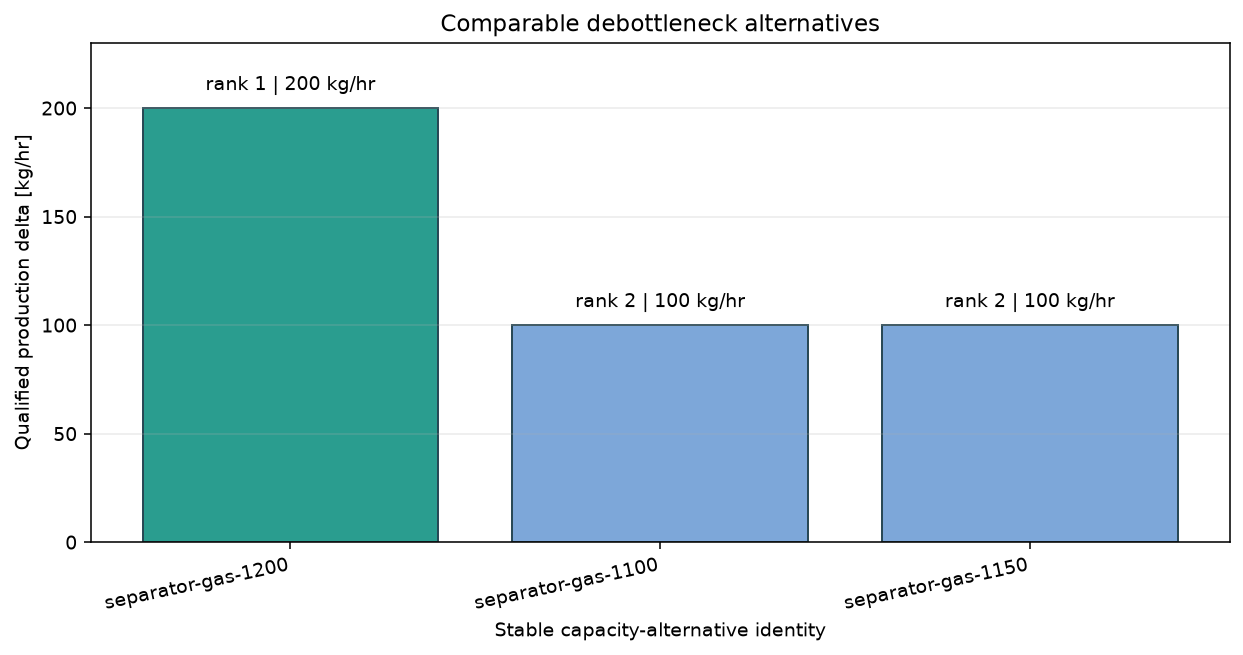

In [10]:
colors = ["#2A9D8F" if rank == 1 else "#7DA7D9" for rank in ranking_table["rank"]]

fig, axis = plt.subplots(figsize=(9, 4.8))
bars = axis.bar(
    ranking_table["alternative_id"],
    ranking_table["delta_kg_hr"],
    color=colors,
    edgecolor="#264653",
)
axis.set_ylabel("Qualified production delta [kg/hr]")
axis.set_xlabel("Stable capacity-alternative identity")
axis.set_title("Comparable debottleneck alternatives")
axis.set_ylim(0.0, 230.0)
axis.grid(axis="y", alpha=0.25)

for bar, rank, delta in zip(
    bars,
    ranking_table["rank"],
    ranking_table["delta_kg_hr"],
):
    axis.text(
        bar.get_x() + bar.get_width() / 2.0,
        delta + 6.0,
        f"rank {rank} | {delta:.0f} kg/hr",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()


## 8. Prove repeatability and Java serialization

The same immutable `StudyResult[]` is ranked again. Rank, identity, and delta must be exactly
stable. The first result is then serialized with Apache Commons Lang's Java-serialization helper
and restored as a detached evidence object. Using the helper also keeps deserialization on the
NeqSim application class loader when this cell is called through JPype.


In [11]:
repeat_result = ranking.rank(study_array)

for first, repeated in zip(
    ranking_result.getRankedCandidates(),
    repeat_result.getRankedCandidates(),
):
    assert first.getRank() == repeated.getRank()
    assert first.getAlternativeDefinition().getId() == (
        repeated.getAlternativeDefinition().getId()
    )
    assert first.getDelta() == repeated.getDelta()

SerializationUtils = JClass("org.apache.commons.lang3.SerializationUtils")
serialized_bytes = SerializationUtils.serialize(ranking_result)
restored_result = SerializationUtils.deserialize(serialized_bytes)

assert restored_result.getOutcome() == ranking_result.getOutcome()
assert restored_result.getBestCandidate().getDelta() == (
    ranking_result.getBestCandidate().getDelta()
)
assert restored_result.getPolicy().getMetricProvenance() == (
    ranking_result.getPolicy().getMetricProvenance()
)

print("Repeat ranking: identical")
print(f"Serialized immutable evidence: {len(serialized_bytes):,} bytes")
print(
    "Restored best alternative: "
    f"{restored_result.getBestCandidate().getAlternativeDefinition().getId()}"
)


Repeat ranking: identical
Serialized immutable evidence: 15,456 bytes
Restored best alternative: separator-gas-1200


## 9. Fail closed on incompatible evidence

Two deliberately invalid submissions demonstrate data-quality behavior:

- one metric declares `t/day` while the ranking policy requires `kg/hr`;
- one capacity proposal has confidence 0.40, below the policy floor of 0.50.

They remain in the immutable result with `NaN` deltas and explicit rejection status instead of
receiving a converted, normalized, weighted, or synthetic score.


In [12]:
wrong_unit = create_study(
    "study-wrong-unit",
    1220.0,
    0.90,
    metric_unit="t/day",
).evaluate()
low_confidence = create_study(
    "study-low-confidence",
    1250.0,
    0.40,
).evaluate()

rejection_input = JArray(StudyResult)(
    [study_results[0], wrong_unit, low_confidence]
)
rejection_result = ranking.rank(rejection_input)

rejection_rows = []
for evidence in rejection_result.getCandidatesInInputOrder():
    diagnostics = " | ".join(str(item) for item in evidence.getDiagnostics())
    rejection_rows.append(
        {
            "alternative_id": evidence.getAlternativeDefinition().getId(),
            "status": str(evidence.getStatus()),
            "delta": float(evidence.getDelta()),
            "diagnostic": diagnostics,
        }
    )

rejection_table = pd.DataFrame(rejection_rows)
display(rejection_table)

assert str(rejection_result.getOutcome()) == "PARTIAL"
assert str(rejection_table.loc[1, "status"]) == "METRIC_METADATA_MISMATCH"
assert str(rejection_table.loc[2, "status"]) == "ALTERNATIVE_CONFIDENCE_TOO_LOW"
assert math.isnan(rejection_table.loc[1, "delta"])
assert math.isnan(rejection_table.loc[2, "delta"])
assert math.isclose(installed_capacity.getDesignValue(), 1000.0)
assert math.isclose(feed.getFlowRate("kg/hr"), 800.0, abs_tol=1.0e-8)

print("Incompatible evidence rejected without a synthetic score")


Incompatible evidence rejected without a synthetic score


,alternative_id,status,delta,diagnostic
0,separator-gas-1100,QUALIFIED,100.0,Paired metric delta is compatible and finite i...
1,separator-gas-1220,METRIC_METADATA_MISMATCH,NaN,Ranking metric metadata does not exactly match...
2,separator-gas-1250,ALTERNATIVE_CONFIDENCE_TOO_LOW,NaN,Alternative confidence is absent or below the ...


## 10. Reusable outputs and engineering interpretation

Verified reusable outputs:

- deterministic area/equipment/constraint/study/alternative/policy/metric identities;
- explicit engineering units, metric basis, provenance, effective period, and confidence;
- installed and proposed scenario evidence, feasibility, restoration, and diagnostics;
- immutable Java-serializable results with array/list entry points for JPype callers;
- qualified ranking plus complete rejected evidence and data-quality status.

For this bounded candidate grid, 1,200 kg/hr is the best qualified installed-capacity alternative,
with a sampled gain of 200 kg/hr. The 1,100 and 1,150 kg/hr proposals both select 1,099 kg/hr and
tie at rank 2. This does not prove that 1,200 kg/hr is a global facility optimum or an approved
project; it only ranks the declared, comparable sampled alternatives.

Remaining integration work belongs outside this notebook: reservoir deliverability curves,
real gathering/export constraints, equipment design verification, economics approval, and
dataset-specific P&ID/instrument/control mapping. No Huldra data or model is used here.


In [13]:
summary = {
    "best_alternative": ranking_result.getBestCandidate()
    .getAlternativeDefinition()
    .getId(),
    "best_delta_kg_hr": float(ranking_result.getBestCandidate().getDelta()),
    "qualified_alternatives": len(ranking_result.getRankedCandidates()),
    "rejected_in_primary_ranking": len(ranking_result.getRejectedCandidates()),
    "installed_limit_restored_kg_hr": installed_capacity.getDesignValue(),
    "process_rate_restored_kg_hr": feed.getFlowRate("kg/hr"),
    "ranking_outcome": str(ranking_result.getOutcome()),
}

summary_table = pd.DataFrame(
    [{"result": key, "value": value} for key, value in summary.items()]
)
display(summary_table)

assert summary["best_alternative"] == "separator-gas-1200"
assert math.isclose(summary["best_delta_kg_hr"], 200.0, abs_tol=1.0e-8)
assert summary["ranking_outcome"] == "COMPLETED"

print("Canonical dependency-13 acceptance workflow completed")


Canonical dependency-13 acceptance workflow completed


,result,value
0,best_alternative,separator-gas-1200
1,best_delta_kg_hr,200.0
2,qualified_alternatives,3
3,rejected_in_primary_ranking,0
4,installed_limit_restored_kg_hr,1000.0
5,process_rate_restored_kg_hr,800.0
6,ranking_outcome,COMPLETED
